## Questão 7 – Análise de Redes

**Enunciado:**  
Faça um código em Python para construir uma representação de Rede a partir da base escolhida ou de atributos derivados dela. Defina nós e arestas de forma coerente com o cenário, gere o grafo em Python e calcule medidas como grau, centralidade ou comunidades, quando fizer sentido. Depois, interprete os resultados e discuta se a análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso escolhido é metodologicamente fraca.

## Raciocínio

Novamente, na Questão 1 a análise inicial já classificava Análise de Redes como uma abordagem de baixa adequação para a base Telco. O motivo é estrutural: os dados representam clientes individuais de forma tabular e não possuem relacionamentos explícitos entre eles. Não existem conexões sociais, histórico de interação ou influência entre clientes que justifiquem naturalmente a construção de uma rede tradicional.

O próprio enunciado da questão levanta essa preocupação ao perguntar se a análise de redes realmente agrega valor ao problema ou se sua aplicação seria metodologicamente fraca. Por isso, a estratégia adotada não foi forçar artificialmente uma rede entre clientes, mas construir grafos que representassem relações legítimas derivadas da estrutura dos dados.

A primeira abordagem foi a criação de uma rede de perfis de serviços. Em vez de conectar clientes diretamente, foram agrupados perfis de contratação semelhantes — combinações de serviços como internet, telefone e streaming. Dois perfis foram conectados quando compartilhavam serviços em comum, com pesos proporcionais à similaridade entre os pacotes.

Essa representação faz sentido no contexto de telecomunicações porque os serviços são organizados em camadas e combinações comerciais. A rede passa a representar a proximidade estrutural entre tipos de portfólio oferecidos pela empresa, e não relações sociais entre usuários.

A segunda abordagem foi a construção de uma rede de correlação entre atributos da própria base. Nesse caso, cada nó representa uma variável, e as conexões indicam associações fortes entre atributos. Foram utilizadas métricas adequadas para diferentes tipos de variáveis, como Cramér’s V para categóricas e correlação point-biserial para relações entre variáveis numéricas e binárias.

Essa segunda rede possui uma interpretação mais sólida metodologicamente, porque transforma em estrutura visual relações estatísticas que já haviam aparecido nas questões anteriores. A ideia principal foi utilizar o grafo como ferramenta de visualização da dependência entre atributos, facilitando a identificação de clusters de variáveis relacionadas e possíveis redundâncias no conjunto de features.

Durante toda a análise, as métricas de rede (como grau, centralidade e comunidades) foram interpretadas com cautela.  
Como os grafos não representam relações sociais reais, não pude utilizar conceitos como “influência” ou “propagação” de forma literal. As medidas foram tratadas apenas como indicadores estruturais de proximidade e conectividade entre perfis ou variáveis.

### Desenvolvimento

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from itertools import combinations
from scipy.stats import chi2_contingency, pointbiserialr

sns.set_theme(style='white')
plt.rcParams['figure.figsize'] = (11, 7)
RANDOM_STATE = 42

In [ ]:
# ── Pré-processamento herdado ─────────────────────────────────────────────────
df_raw = pd.read_csv('../../data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
print(f'Base: {df.shape[0]} clientes × {df.shape[1]} colunas')

Base: 7043 clientes × 21 colunas


---
## Parte 1 — Rede de perfis de portfólio de serviços

In [ ]:
# ── Definição dos nós: perfis únicos de combinação de serviços ────────────────
# Cada nó é um perfil distinto de pacote contratado.
# O perfil é a combinação de: PhoneService, InternetService + 7 serviços binários

PROFILE_COLS = [
    'PhoneService', 'InternetService',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Criamos o rótulo de perfil e agregamos métricas por perfil
df['profile'] = df[PROFILE_COLS].apply(
    lambda row: '|'.join(row.astype(str)), axis=1
)

profile_stats = (
    df.groupby('profile')
    .agg(
        n_clientes     = ('Churn_bin', 'count'),
        churn_rate     = ('Churn_bin', 'mean'),
        monthly_median = ('MonthlyCharges', 'median'),
        tenure_median  = ('tenure', 'median')
    )
    .reset_index()
)
profile_stats['churn_pct'] = (profile_stats['churn_rate'] * 100).round(1)

# Filtramos os perfis com ao menos 20 clientes para garantir estimativas estáveis
MIN_CLIENTES = 20
profile_stats = profile_stats[profile_stats['n_clientes'] >= MIN_CLIENTES].reset_index(drop=True)

print(f'Perfis únicos com n ≥ {MIN_CLIENTES}: {len(profile_stats)}')
print(f'Cobertura: {profile_stats.n_clientes.sum()} de {len(df)} clientes '
      f'({profile_stats.n_clientes.sum()/len(df)*100:.1f}%)')
print(f'\nTop 5 perfis por tamanho:')
display(profile_stats.sort_values('n_clientes', ascending=False).head(5)[
    ['profile','n_clientes','churn_pct','monthly_median','tenure_median']
])

Perfis únicos com n ≥ 20: 76
Cobertura: 5039 de 7043 clientes (71.5%)

Top 5 perfis por tamanho:


,profile,n_clientes,churn_pct,monthly_median,tenure_median
74,Yes|No|No|No|No|No|No|No|No,1184,8.7,19.95,19.0
75,Yes|No|Yes|No|No|No|No|No|No,342,2.9,25.00,52.0
32,Yes|Fiber optic|No|No|No|No|No|No|No,233,59.2,70.05,3.0
9,Yes|DSL|No|No|No|No|No|No|No,170,41.2,45.00,2.0
46,Yes|Fiber optic|Yes|No|No|No|No|No|No,166,62.0,74.95,8.0


In [ ]:
# ── Definição das arestas: serviços compartilhados entre perfis ───────────────
# Dois perfis são conectados se compartilham ≥ SHARED_MIN serviços em comum.
# Peso da aresta = número de serviços compartilhados (0–9).
# Isso representa adjacência de portfólio, ou seja, perfis vizinhos são aqueles
# que diferem por apenas um ou dois serviços: migrações prováveis.

SHARED_MIN = 6   # mínimo de serviços compartilhados para criar aresta

def count_shared_services(p1, p2):
    """Conta atributos de serviço com o mesmo valor entre dois perfis."""
    v1 = p1.split('|')
    v2 = p2.split('|')
    return sum(a == b for a, b in zip(v1, v2))

edges = []
profiles = profile_stats['profile'].tolist()
for i, j in combinations(range(len(profiles)), 2):
    shared = count_shared_services(profiles[i], profiles[j])
    if shared >= SHARED_MIN:
        edges.append((i, j, shared))

print(f'Arestas criadas (serviços compartilhados ≥ {SHARED_MIN}): {len(edges)}')
print(f'Distribuição dos pesos de aresta (serviços compartilhados):')
pesos = [e[2] for e in edges]
print(pd.Series(pesos).value_counts().sort_index().to_string())

Arestas criadas (serviços compartilhados ≥ 6): 1087
Distribuição dos pesos de aresta (serviços compartilhados):
6    562
7    375
8    150


In [ ]:
# ── Construção do grafo ───────────────────────────────────────────────────────
G = nx.Graph()

# Adicionamos nós com atributos
for idx, row in profile_stats.iterrows():
    G.add_node(
        idx,
        n_clientes    = int(row['n_clientes']),
        churn_pct     = float(row['churn_pct']),
        monthly_med   = float(row['monthly_median']),
        tenure_med    = float(row['tenure_median']),
        label         = f"P{idx}\n({row['n_clientes']}cl, {row['churn_pct']}%)"
    )

# Adicionamos arestas com peso
for i, j, w in edges:
    G.add_edge(i, j, weight=w)

print(f'Grafo construído:')
print(f'  Nós    : {G.number_of_nodes()}')
print(f'  Arestas: {G.number_of_edges()}')
print(f'  Densidade: {nx.density(G):.4f}')
print(f'  Componentes conectados: {nx.number_connected_components(G)}')
print(f'  Grafo conectado: {nx.is_connected(G)}')

Grafo construído:
  Nós    : 76
  Arestas: 1087
  Densidade: 0.3814
  Componentes conectados: 1
  Grafo conectado: True


In [ ]:
# ── Métricas estruturais do grafo (como visto no Aula 14) ────────────

# Centralidade de grau: quantas conexões cada perfil tem
degree_centrality     = nx.degree_centrality(G)

# Centralidade de intermediação: quantos caminhos passam pelo nó
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# Coeficiente de agrupamento: quão clusterizados são os vizinhos
clustering            = nx.clustering(G, weight='weight')

# Monta tabela de métricas por nó
node_metrics = pd.DataFrame({
    'perfil_idx'          : list(G.nodes()),
    'n_clientes'          : [G.nodes[n]['n_clientes'] for n in G.nodes()],
    'churn_pct'           : [G.nodes[n]['churn_pct']  for n in G.nodes()],
    'grau'                : [G.degree(n) for n in G.nodes()],
    'centralidade_grau'   : [round(degree_centrality[n], 4) for n in G.nodes()],
    'centralidade_interm' : [round(betweenness_centrality[n], 4) for n in G.nodes()],
    'coef_agrupamento'    : [round(clustering[n], 4) for n in G.nodes()],
}).sort_values('centralidade_grau', ascending=False).reset_index(drop=True)

print('=== Métricas por nó (perfil de portfólio) — top 10 por centralidade de grau ===')
display(node_metrics.head(10))

=== Métricas por nó (perfil de portfólio) — top 10 por centralidade de grau ===


,perfil_idx,n_clientes,churn_pct,grau,centralidade_grau,centralidade_interm,coef_agrupamento
0,32,233,59.2,40,0.5333,0.0086,0.5275
1,47,77,72.7,39,0.5200,0.0122,0.5217
2,39,48,54.2,39,0.5200,0.0151,0.4931
3,46,166,62.0,39,0.5200,0.0092,0.5362
4,49,110,66.4,39,0.5200,0.0145,0.5044
5,33,61,63.9,38,0.5067,0.0160,0.4879
6,23,44,36.4,37,0.4933,0.0095,0.5352
7,34,69,73.9,37,0.4933,0.0157,0.4929
8,56,64,50.0,37,0.4933,0.0144,0.4949
9,48,61,59.0,37,0.4933,0.0119,0.5212


In [ ]:
# ── Detecção de comunidades (Greedy Modularity) ──────────────────────────────
# Aqui identificamos grupos de perfis fortemente conectados entre si.
# No contexto de portfólio: comunidades = clusters de pacotes de serviço similares.

# Usamos apenas o maior componente conectado para garantir aplicabilidade
largest_cc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
communities_raw = nx.community.greedy_modularity_communities(largest_cc, weight='weight')
communities = [sorted(c) for c in communities_raw]

print(f'Número de comunidades detectadas: {len(communities)}')
for i, comm in enumerate(communities):
    nodes_in_comm = [n for n in comm]
    churn_vals = [G.nodes[n]['churn_pct'] for n in nodes_in_comm]
    n_clients  = [G.nodes[n]['n_clientes'] for n in nodes_in_comm]
    print(f'  Comunidade {i+1}: {len(nodes_in_comm)} perfis | '
          f'churn médio ponderado: {np.average(churn_vals, weights=n_clients):.1f}% | '
          f'clientes: {sum(n_clients)}')

# Mapeamos a comunidade para cada nó
community_map = {}
for i, comm in enumerate(communities):
    for n in comm:
        community_map[n] = i
nx.set_node_attributes(largest_cc, community_map, 'community')

Número de comunidades detectadas: 2
  Comunidade 1: 39 perfis | churn médio ponderado: 35.5% | clientes: 1804
  Comunidade 2: 37 perfis | churn médio ponderado: 26.2% | clientes: 3235


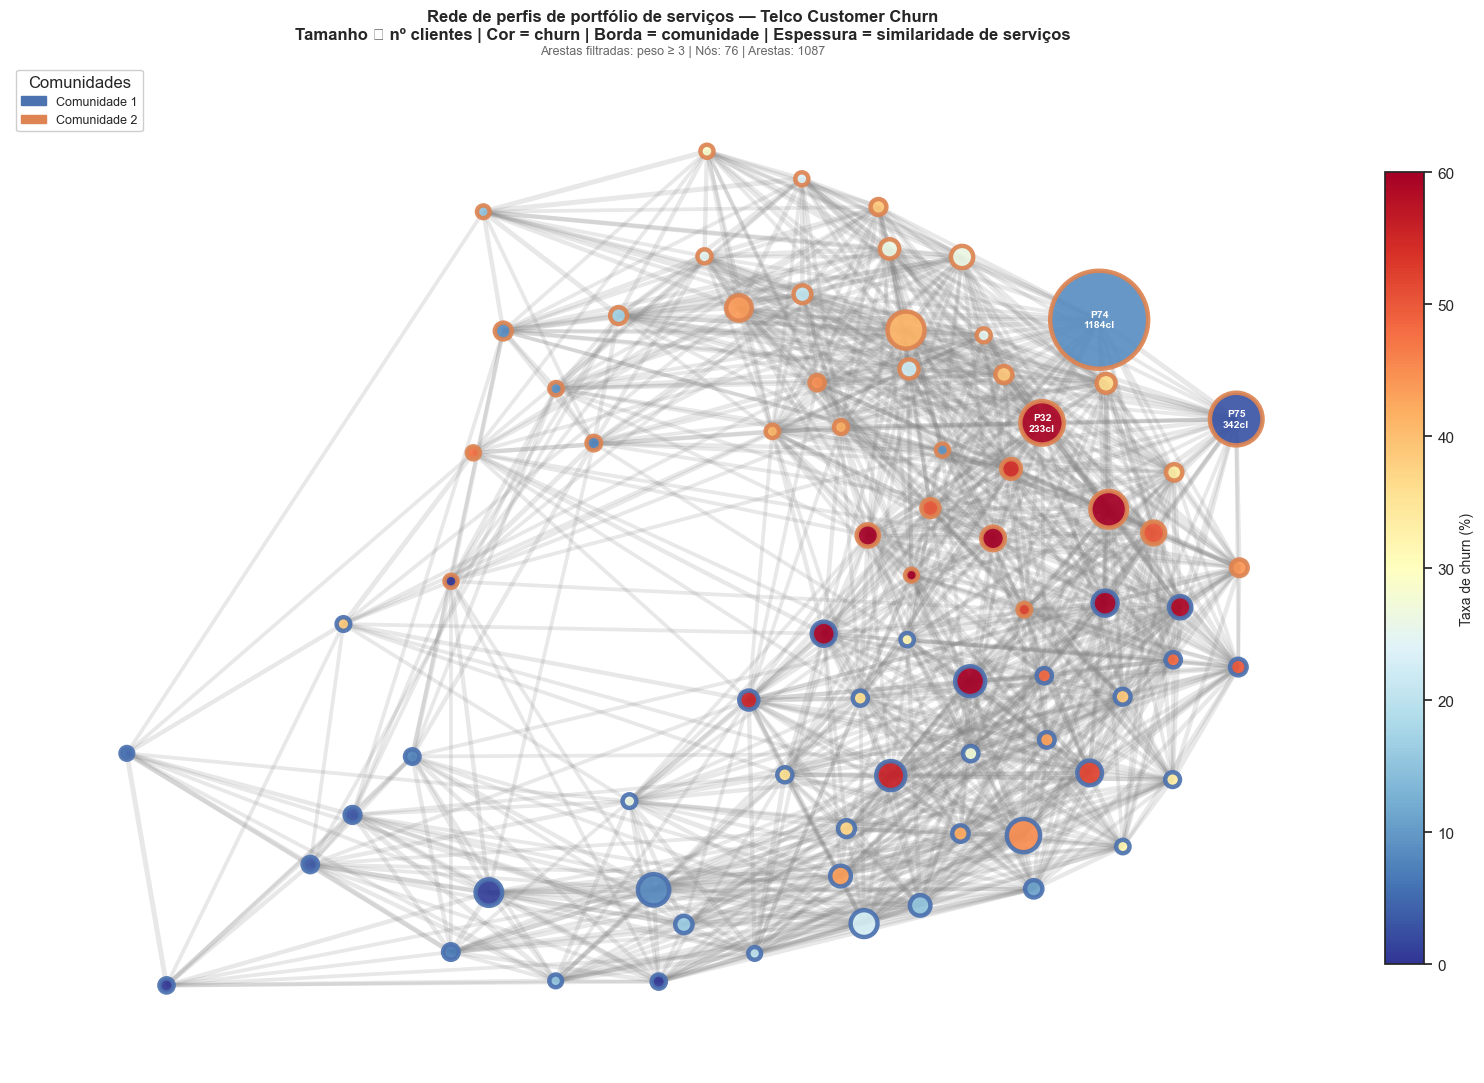

In [ ]:
# ── Gráfico 1: Rede de perfis de portfólio ────────────────────────────────────
# Tamanho do nó ∝ número de clientes
# Cor do nó ∝ taxa de churn (vermelho = alto churn, azul = baixo churn)
# Espessura da aresta ∝ peso (serviços compartilhados)

# Filtramos apenas conexões relevantes
MIN_EDGE_WEIGHT = 3

G_plot = nx.Graph(
    (
        u, v, d
    )
    for u, v, d in largest_cc.edges(data=True)
    if d['weight'] >= MIN_EDGE_WEIGHT
)

# Reinserimos os atributos dos nós
for n in G_plot.nodes():
    G_plot.nodes[n].update(largest_cc.nodes[n])

fig, ax = plt.subplots(figsize=(15, 11))

# Layout do grafo
pos = nx.spring_layout(
    G_plot,
    seed=RANDOM_STATE,
    k=2.0,
    iterations=200
)

# ── Atributos visuais ─────────────────────────────────────────────────────────
community_colors = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52',
    '#8172B2', '#937860', '#DA8BC3', '#8C8C8C'
]

node_sizes = [
    G_plot.nodes[n]['n_clientes'] * 4.2
    for n in G_plot.nodes()
]

node_colors = [
    G_plot.nodes[n]['churn_pct']
    for n in G_plot.nodes()
]

node_border_colors = [
    community_colors[
        community_map.get(n, 0) % len(community_colors)
    ]
    for n in G_plot.nodes()
]

edge_widths = [
    G_plot[u][v]['weight'] * 0.45
    for u, v in G_plot.edges()
]

# ── Desenha arestas primeiro ──────────────────────────────────────────────────
nx.draw_networkx_edges(
    G_plot,
    pos,
    ax=ax,
    width=edge_widths,
    alpha=0.18,
    edge_color='gray'
)

# ── Desenha nós ───────────────────────────────────────────────────────────────
nodes = nx.draw_networkx_nodes(
    G_plot,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.RdYlBu_r,
    vmin=0,
    vmax=60,
    edgecolors=node_border_colors,
    linewidths=3.2,
    alpha=0.92
)

# ── Labels apenas em nós relevantes ──────────────────────────────────────────
big_nodes = {
    n: f"P{n}\n{G_plot.nodes[n]['n_clientes']}cl"
    for n in G_plot.nodes()
    if G_plot.nodes[n]['n_clientes'] > 200
}

nx.draw_networkx_labels(
    G_plot,
    pos,
    labels=big_nodes,
    ax=ax,
    font_size=7.5,
    font_color='white',
    font_weight='bold'
)

# ── Colorbar de churn ─────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlBu_r,
    norm=plt.Normalize(vmin=0, vmax=60)
)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    fraction=0.028,
    pad=0.02
)

cbar.set_label(
    'Taxa de churn (%)',
    fontsize=10
)

# ── Legenda das comunidades ───────────────────────────────────────────────────
patches = [
    mpatches.Patch(
        color=community_colors[i % len(community_colors)],
        label=f'Comunidade {i+1}'
    )
    for i in range(len(communities))
]

legend = ax.legend(
    handles=patches,
    loc='upper left',
    fontsize=9,
    title='Comunidades',
    frameon=True
)

legend.get_frame().set_alpha(0.95)

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title(
    'Rede de perfis de portfólio de serviços — Telco Customer Churn\n'
    'Tamanho ∝ nº clientes | Cor = churn | '
    'Borda = comunidade | Espessura = similaridade de serviços',
    fontsize=12,
    pad=18,
    fontweight='bold'
)

# Subtítulo técnico
ax.text(
    0.5,
    1.01,
    f'Arestas filtradas: peso ≥ {MIN_EDGE_WEIGHT} '
    f'| Nós: {G_plot.number_of_nodes()} '
    f'| Arestas: {G_plot.number_of_edges()}',
    transform=ax.transAxes,
    ha='center',
    fontsize=9,
    color='dimgray'
)

ax.axis('off')

plt.tight_layout()
plt.show()

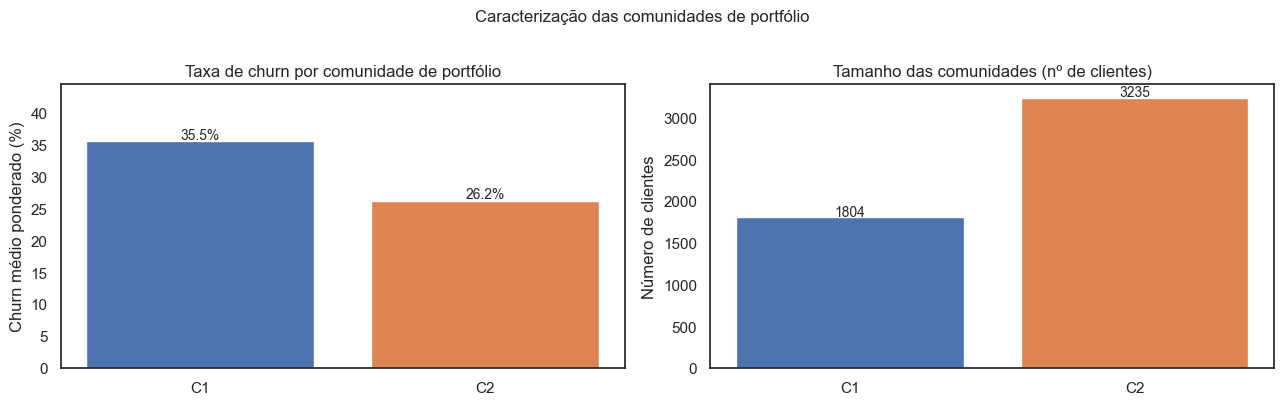

Tabela de comunidades:


,Comunidade,Perfis,Clientes,Churn médio pond. (%),MonthlyCharges mediano
0,C1,39,1804,35.5,94.90
1,C2,37,3235,26.2,55.02


In [23]:
# ── Gráfico 2: Churn por comunidade ─────────────────────────────────────────
comm_summary = []
for i, comm in enumerate(communities):
    nodes_in = [n for n in comm if n in largest_cc.nodes()]
    if not nodes_in:
        continue
    churn_vals  = [largest_cc.nodes[n]['churn_pct']  for n in nodes_in]
    n_clients   = [largest_cc.nodes[n]['n_clientes'] for n in nodes_in]
    monthly_vals= [largest_cc.nodes[n]['monthly_med'] for n in nodes_in]
    comm_summary.append({
        'Comunidade'              : f'C{i+1}',
        'Perfis'                  : len(nodes_in),
        'Clientes'                : sum(n_clients),
        'Churn médio pond. (%)'   : round(np.average(churn_vals, weights=n_clients), 1),
        'MonthlyCharges mediano'  : round(np.median(monthly_vals), 2),
    })

df_comm = pd.DataFrame(comm_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(df_comm['Comunidade'], df_comm['Churn médio pond. (%)'],
            color=[community_colors[i % len(community_colors)] for i in range(len(df_comm))],
            edgecolor='white')
for i, row in df_comm.iterrows():
    axes[0].text(i, row['Churn médio pond. (%)'] + 0.4,
                 f"{row['Churn médio pond. (%)']:.1f}%",
                 ha='center', fontsize=10)
axes[0].set_ylabel('Churn médio ponderado (%)')
axes[0].set_title('Taxa de churn por comunidade de portfólio')
axes[0].set_ylim(0, max(df_comm['Churn médio pond. (%)']) * 1.25)

axes[1].bar(df_comm['Comunidade'], df_comm['Clientes'],
            color=[community_colors[i % len(community_colors)] for i in range(len(df_comm))],
            edgecolor='white')
for i, row in df_comm.iterrows():
    axes[1].text(i, row['Clientes'] + 20,
                 str(row['Clientes']),
                 ha='center', fontsize=10)
axes[1].set_ylabel('Número de clientes')
axes[1].set_title('Tamanho das comunidades (nº de clientes)')

plt.suptitle('Caracterização das comunidades de portfólio', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

print('Tabela de comunidades:')
display(df_comm)

In [11]:
# ── Métricas globais do grafo ─────────────────────────────────────────────────
if nx.is_connected(largest_cc):
    avg_path = round(nx.average_shortest_path_length(largest_cc, weight=None), 4)
    diameter = nx.diameter(largest_cc)
else:
    avg_path = None
    diameter = None

global_metrics = {
    'Nós (perfis)'               : largest_cc.number_of_nodes(),
    'Arestas'                    : largest_cc.number_of_edges(),
    'Densidade'                  : round(nx.density(largest_cc), 4),
    'Comprimento médio do caminho': avg_path,
    'Diâmetro'                   : diameter,
    'Coef. agrupamento médio'    : round(nx.average_clustering(largest_cc, weight='weight'), 4),
    'Comunidades'                : len(communities),
    'Modularidade (estimada)'    : round(nx.community.modularity(
        largest_cc, communities_raw, weight='weight'), 4)
}

print('=== Métricas globais da rede de portfólios ===')
for k, v in global_metrics.items():
    print(f'  {k}: {v}')

=== Métricas globais da rede de portfólios ===
  Nós (perfis): 76
  Arestas: 1087
  Densidade: 0.3814
  Comprimento médio do caminho: 1.7396
  Diâmetro: 3
  Coef. agrupamento médio: 0.5271
  Comunidades: 2
  Modularidade (estimada): 0.2934


---
## Parte 2 — Rede de correlação entre atributos

In [ ]:
# ── Construção da rede de dependência entre variáveis ─────────────────────────
# Nós = atributos da base | Arestas = associação acima de limiar
# Método por tipo de par:
#   cat-cat  → V de Cramér
#   num-num  → correlação de Pearson (|r|)
#   num-cat  → point-biserial com target binário derivado
# Limiar: associação ≥ 0.20 (moderada)

ASSOC_THRESHOLD = 0.20

ANALYSIS_COLS = [
    'tenure','MonthlyCharges','TotalCharges',
    'Contract','InternetService','PaymentMethod',
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'PaperlessBilling','SeniorCitizen','Partner','Dependents','Churn'
]
NUM_VARS = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']
CAT_VARS = [c for c in ANALYSIS_COLS if c not in NUM_VARS]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = len(x)
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / min(k-1, r-1)) if min(k-1, r-1) > 0 else 0.0

def association(col_a, col_b, df):
    a_num = col_a in NUM_VARS
    b_num = col_b in NUM_VARS
    if a_num and b_num:
        return abs(df[col_a].corr(df[col_b]))
    elif not a_num and not b_num:
        return cramers_v(df[col_a], df[col_b])
    else:
        num_col = col_a if a_num else col_b
        cat_col = col_b if a_num else col_a
        dummies = pd.get_dummies(df[cat_col], drop_first=True)
        return max(abs(pointbiserialr(df[num_col], dummies[c])[0])
                   for c in dummies.columns)

# Calculamos todas as associações par-a-par
assoc_edges = []
for col_a, col_b in combinations(ANALYSIS_COLS, 2):
    try:
        score = association(col_a, col_b, df)
        if score >= ASSOC_THRESHOLD:
            assoc_edges.append((col_a, col_b, round(score, 4)))
    except Exception:
        pass

print(f'Pares com associação ≥ {ASSOC_THRESHOLD}: {len(assoc_edges)}')

Pares com associação ≥ 0.2: 85


In [13]:
# ── Grafo de correlação entre atributos ───────────────────────────────────────
G_attr = nx.Graph()
G_attr.add_nodes_from(ANALYSIS_COLS)
for a, b, w in assoc_edges:
    G_attr.add_edge(a, b, weight=w)

# Tipo de cada variável para cor dos nós
node_type_colors = {
    col: ('#4C72B0' if col in NUM_VARS
          else '#C44E52' if col == 'Churn'
          else '#55A868')
    for col in ANALYSIS_COLS
}

# Centralidade de grau
attr_degree = dict(nx.degree_centrality(G_attr))
attr_between = dict(nx.betweenness_centrality(G_attr, weight='weight'))

print('Top 8 atributos por centralidade de grau (rede de correlação):')
top_attr = sorted(attr_degree.items(), key=lambda x: x[1], reverse=True)[:8]
for var, cent in top_attr:
    print(f'  {var:25s}: grau={G_attr.degree(var):2d} | centralidade={cent:.4f} | '
          f'intermediação={attr_between[var]:.4f}')

Top 8 atributos por centralidade de grau (rede de correlação):
  InternetService          : grau=15 | centralidade=0.8333 | intermediação=0.0719
  MonthlyCharges           : grau=14 | centralidade=0.7778 | intermediação=0.0850
  tenure                   : grau=13 | centralidade=0.7222 | intermediação=0.0654
  TotalCharges             : grau=13 | centralidade=0.7222 | intermediação=0.0000
  DeviceProtection         : grau=12 | centralidade=0.6667 | intermediação=0.0392
  PaymentMethod            : grau=11 | centralidade=0.6111 | intermediação=0.1307
  StreamingTV              : grau=11 | centralidade=0.6111 | intermediação=0.0065
  StreamingMovies          : grau=11 | centralidade=0.6111 | intermediação=0.0196


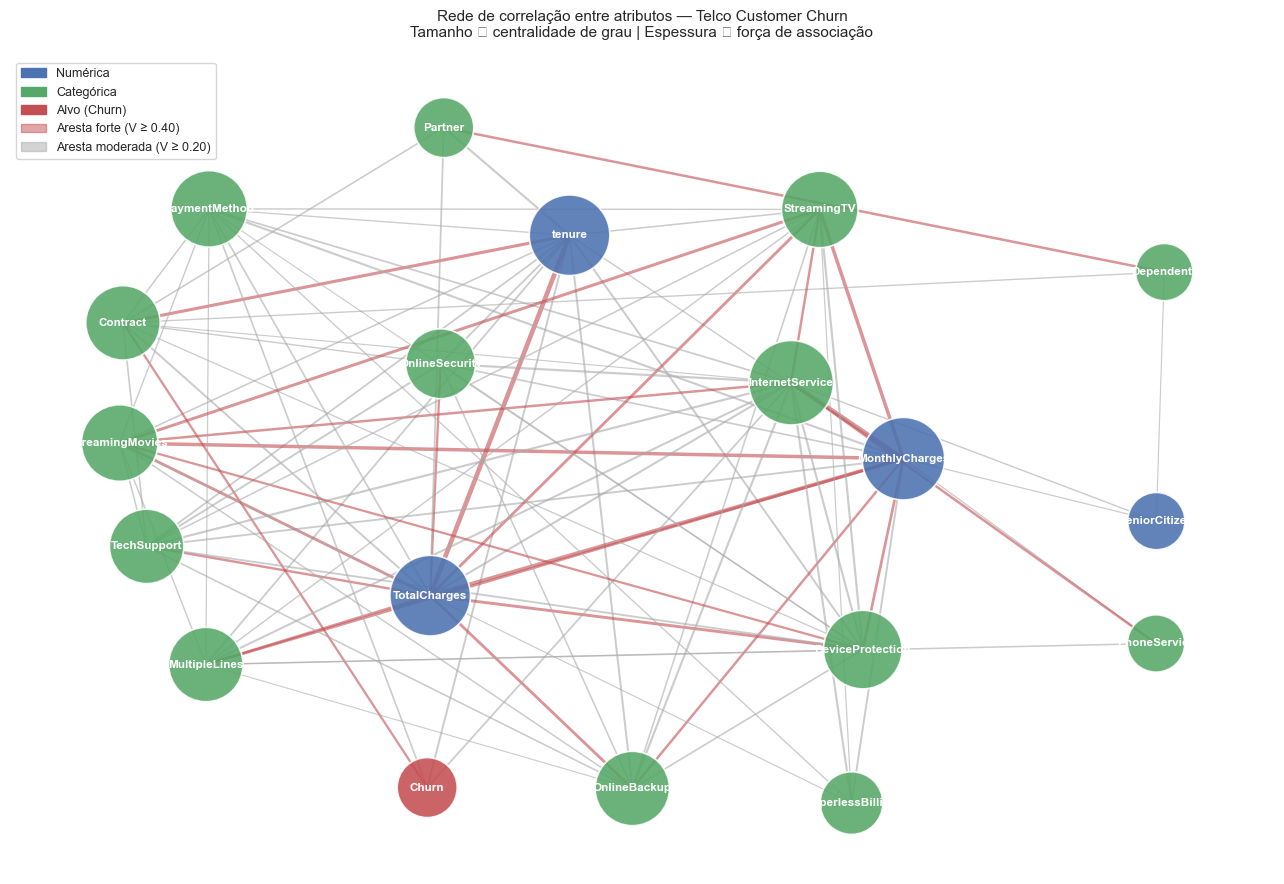

In [15]:
# ── Gráfico 3: Rede de correlação entre atributos ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

pos_attr = nx.spring_layout(G_attr, seed=RANDOM_STATE, k=2.2, weight='weight')

node_colors_attr = [node_type_colors[n] for n in G_attr.nodes()]
node_sizes_attr  = [1200 + attr_degree[n] * 3000 for n in G_attr.nodes()]
edge_widths_attr = [G_attr[u][v]['weight'] * 4 for u, v in G_attr.edges()]
edge_colors_attr = ['#C44E52' if G_attr[u][v]['weight'] >= 0.4
                    else '#aaaaaa' for u, v in G_attr.edges()]

nx.draw_networkx_nodes(
    G_attr, pos_attr, ax=ax,
    node_size=node_sizes_attr,
    node_color=node_colors_attr,
    alpha=0.88, linewidths=1.2, edgecolors='white'
)
nx.draw_networkx_edges(
    G_attr, pos_attr, ax=ax,
    width=edge_widths_attr,
    edge_color=edge_colors_attr,
    alpha=0.6
)
nx.draw_networkx_labels(
    G_attr, pos_attr, ax=ax,
    font_size=8.5, font_color='white', font_weight='bold'
)

legend_patches = [
    mpatches.Patch(color='#4C72B0', label='Numérica'),
    mpatches.Patch(color='#55A868', label='Categórica'),
    mpatches.Patch(color='#C44E52', label='Alvo (Churn)'),
    mpatches.Patch(color='#C44E52', alpha=0.5, label='Aresta forte (V ≥ 0.40)'),
    mpatches.Patch(color='#aaaaaa', alpha=0.5, label='Aresta moderada (V ≥ 0.20)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title(
    'Rede de correlação entre atributos — Telco Customer Churn\n'
    'Tamanho ∝ centralidade de grau | Espessura ∝ força de associação',
    fontsize=11, pad=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ── Valor analítico da rede de correlação ─────────────────────────────────────
# Identificamos variáveis com alta intermediação → "pontes" entre clusters
# e variáveis com alta centralidade de grau → hubs de informação

attr_metrics_df = pd.DataFrame({
    'variavel'          : list(G_attr.nodes()),
    'grau'              : [G_attr.degree(n) for n in G_attr.nodes()],
    'cent_grau'         : [round(attr_degree[n], 4) for n in G_attr.nodes()],
    'cent_interm'       : [round(attr_between[n], 4) for n in G_attr.nodes()],
    'tipo'              : ['numérica' if n in NUM_VARS
                           else 'alvo' if n == 'Churn'
                           else 'categórica'
                           for n in G_attr.nodes()]
}).sort_values('cent_grau', ascending=False).reset_index(drop=True)

print('Ranking de atributos por centralidade de grau na rede de correlação:')
display(attr_metrics_df)

Ranking de atributos por centralidade de grau na rede de correlação:


,variavel,grau,cent_grau,cent_interm,tipo
0,InternetService,15,0.8333,0.0719,categórica
1,MonthlyCharges,14,0.7778,0.0850,numérica
2,tenure,13,0.7222,0.0654,numérica
3,TotalCharges,13,0.7222,0.0000,numérica
4,DeviceProtection,12,0.6667,0.0392,categórica
5,PaymentMethod,11,0.6111,0.1307,categórica
6,StreamingTV,11,0.6111,0.0065,categórica
7,StreamingMovies,11,0.6111,0.0196,categórica
8,MultipleLines,10,0.5556,0.0458,categórica
9,OnlineBackup,10,0.5556,0.0196,categórica


## Conclusão da Questão 7

A análise realizada confirma que a aplicação de redes ao problema principal de churn da base Telco possui limitações metodológicas significativas. O problema continua sendo, essencialmente, um cenário de classificação supervisionada em dados tabulares, onde modelos como Regressão Logística e Árvore de Decisão se mostraram mais adequados e mais eficientes nas questões anteriores.

Mesmo assim, a análise de redes trouxe algum valor analítico em dois contextos específicos: organização dos perfis de serviço e visualização da estrutura de dependência entre atributos.

A rede de perfis de serviços conseguiu identificar agrupamentos coerentes de pacotes contratados pelos clientes. Comunidades relacionadas a clientes com apenas telefonia, apenas internet ou pacotes completos apareceram de forma relativamente bem definida. Além disso, foi possível observar diferenças relevantes nas taxas médias de _churn_ entre esses grupos, reforçando resultados já encontrados anteriormente sobre o impacto do tipo de contrato e dos serviços adicionais na evasão de clientes.

No entanto, essa rede possui uma limitação importante: as conexões entre perfis não foram observadas diretamente nos dados, mas definidas artificialmente a partir da similaridade dos serviços contratados. Isso significa que o grafo representa uma estrutura de produto, e não uma rede real de comportamento ou interação entre clientes. Consequentemente, métricas como centralidade devem ser interpretadas apenas como medidas de proximidade estrutural entre perfis e não como indicadores de influência.

A parte mais relevante da questão acabou sendo a rede de correlação entre atributos. Ela tornou visualmente explícitas várias dependências que já haviam sido identificadas nas questões anteriores. Variáveis como `Contract`, `tenure`, `MonthlyCharges` e `TotalCharges` apareceram como nós altamente conectados, confirmando seu papel central no problema de _churn_.

O cluster formado entre `tenure`, `MonthlyCharges` e `TotalCharges` foi especialmente importante porque reforçou visualmente dois pontos já discutidos anteriormente:

* a violação da independência condicional do Naive Bayes;
* a relação multiplicativa explorada na regressão da Q3.

Nesse sentido, a análise de redes não produziu descobertas completamente novas, mas ajudou a comunicar de forma mais intuitiva relações estatísticas já observadas numericamente.

O principal valor da abordagem, portanto, não está em melhorar o desempenho preditivo do problema de _churn_, mas em fornecer uma camada adicional de visualização e interpretação estrutural dos dados. Para públicos menos técnicos, a representação em forma de grafo pode ser mais acessível do que tabelas de correlação ou heatmaps tradicionais.

Assim, a conclusão mais adequada é que a análise de redes possui utilidade limitada para o problema central da base Telco, mas ainda pode contribuir como ferramenta complementar de exploração visual e comunicação analítica.